In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import important libraries

import pandas as pd              # for data handling
import numpy as np               # numerical operations
import matplotlib.pyplot as plt  # plotting graphs
import seaborn as sns            # advanced visualization

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [6]:
# Load dataset

data = pd.read_csv("Advertising.csv")

# Show first 5 rows
print(data.head())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [7]:
# Dataset information

print(data.info())

# Statistical summary
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400

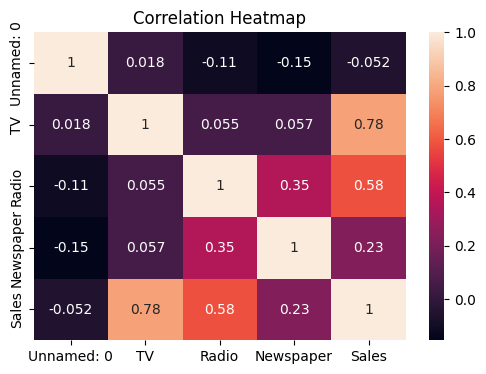

In [8]:
# Check correlation between variables

plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# Features (input variables)

X = data[['TV','Radio','Newspaper']]

# Target variable

y = data['Sales']

In [10]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# Create Linear Regression model

model = LinearRegression()

# Train model

model.fit(X_train, y_train)

LinearRegression()

In [12]:
# Predict sales using test data

y_pred = model.predict(X_test)

print(y_pred)

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967  9.04831992  6.65328312
 14.34554487  8.90349333  9.68959028 12.16494386  8.73628397 16.26507258
 10.27759582 18.83109103 19.56036653 13.25103464 12.33620695 21.30695132
  7.82740305  5.80957448 20.75753231 11.98138077  9.18349576  8.5066991
 12.46646769 10.00337695 21.3876709  12.24966368 18.26661538 20.13766267
 14.05514005 20.85411186 11.0174441   4.56899622]


In [13]:
# Calculate error

error = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", error)

Mean Absolute Error: 1.4607567168117603


In [14]:
# Accuracy of model

score = r2_score(y_test, y_pred)

print("R2 Score:", score)

R2 Score: 0.899438024100912


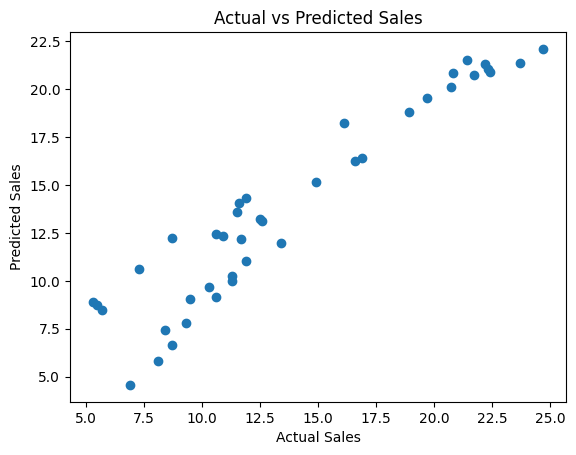

In [15]:
# Plot comparison graph

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [16]:
# Predict sales for new data

new_data = [[150,25,20]]

prediction = model.predict(new_data)

print("Predicted Sales:", prediction)

Predicted Sales: [14.4735936]


/home/admin1/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


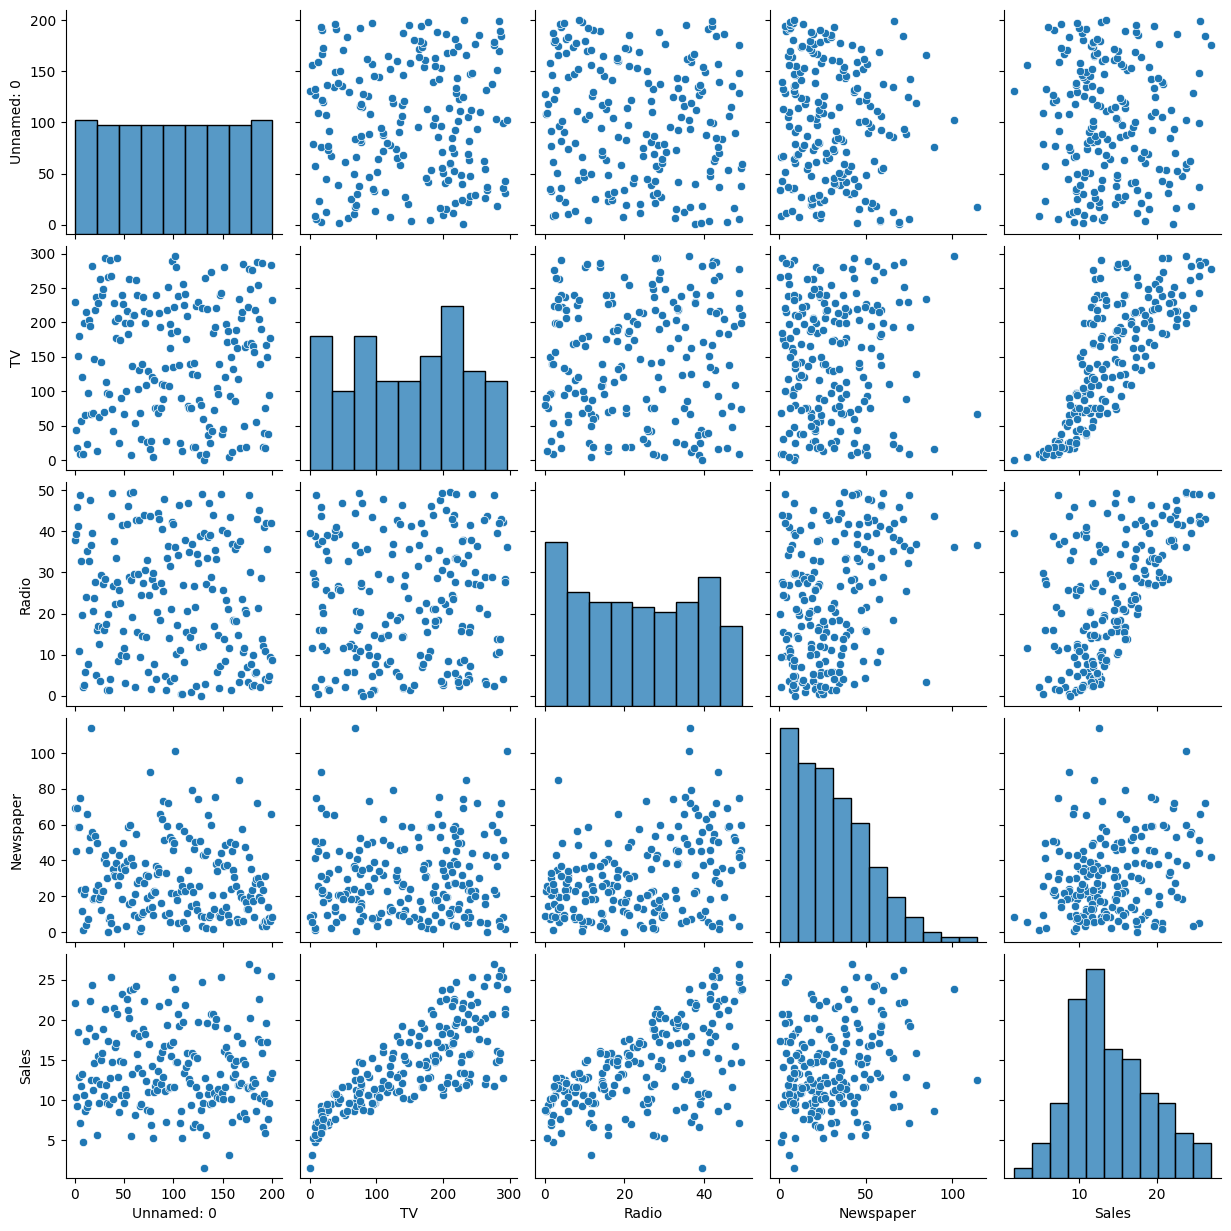

In [17]:
# Pairplot visualization

sns.pairplot(data)
plt.show()

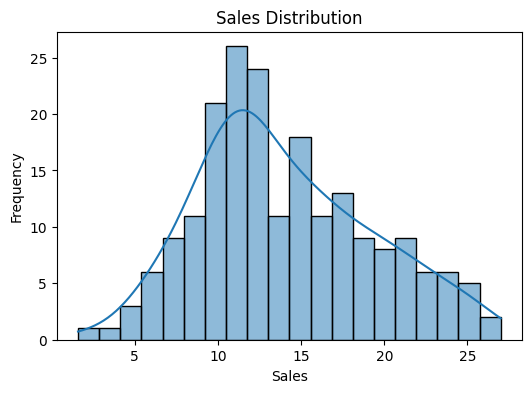

In [18]:
# Sales distribution

plt.figure(figsize=(6,4))

sns.histplot(data['Sales'], bins=20, kde=True)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

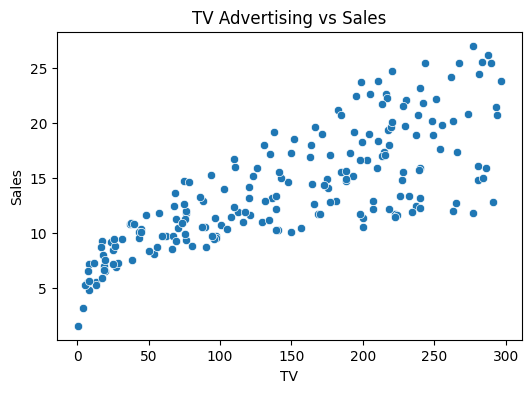

In [19]:
# TV vs Sales

plt.figure(figsize=(6,4))

sns.scatterplot(x='TV', y='Sales', data=data)

plt.title("TV Advertising vs Sales")

plt.show()

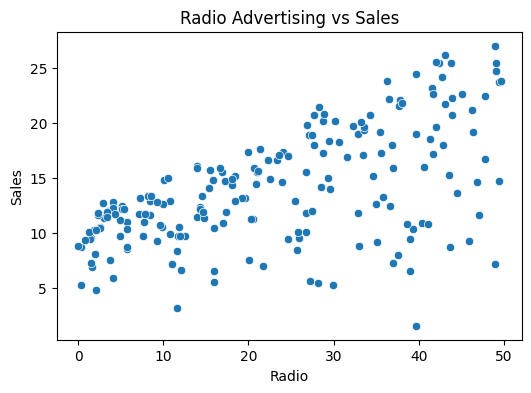

In [20]:
# Radio vs Sales

plt.figure(figsize=(6,4))

sns.scatterplot(x='Radio', y='Sales', data=data)

plt.title("Radio Advertising vs Sales")

plt.show()

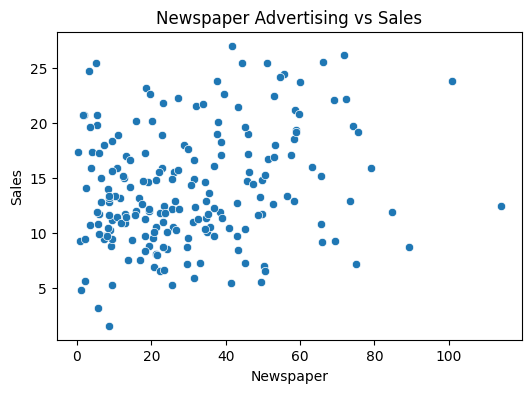

In [21]:
# Newspaper vs Sales

plt.figure(figsize=(6,4))

sns.scatterplot(x='Newspaper', y='Sales', data=data)

plt.title("Newspaper Advertising vs Sales")

plt.show()

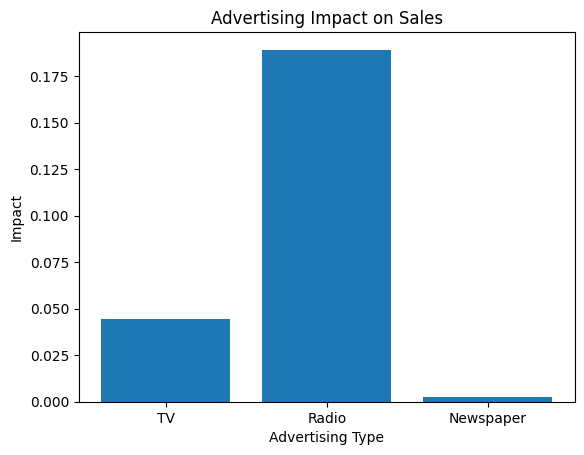

In [22]:
# Feature importance

importance = model.coef_

features = ['TV','Radio','Newspaper']

plt.bar(features, importance)

plt.title("Advertising Impact on Sales")
plt.xlabel("Advertising Type")
plt.ylabel("Impact")

plt.show()